# ALYA workshop

## Introduction

*This* workshop aims to briefly introduce users to the necessary pre- and postprocessing procedures, in order to configure, run and evaluate the results of the simulations in ALYA.

----

## Pre-processing

### Basic files

Running cases in ALYA requires the configuration of different input files. There are two sets of files; the mandatory ones, i.e. related to the configuration of the simulation engine, the geometry definition, etc.

- left_ventricle.**dat**
- left_ventricle.**dom.dat**
- left_ventricle.**ker.dat**

Additionally there are optional files, related to the physics simulated, i.e. module- and geometry-specific files:

- left_ventricle.**exm.dat**
- left_ventricle.**sld.dat**


We are now going to focus on specific sections of each input file, that are relevant to configuring the case of interest.

### General remarks

Before we dive into the specifics of the different files, we need to specify a few things regarding the formatting. Specifically:

- Comments in ALYA configuration files are signified with the **$** character.
- The `INCLUDE` statement introduces the content of the specified file, in place.
- Despite providing the full names for clarity, ALYA recognizes the first **5** letters of each word, therefore the user does not need to worry about i.e. inputting `ITERATION` instead of `ITERATIONS`, etc.

#### left_ventricle.**dat**


This is the central file of the simulation providing general information such as the timeframe of the simulation, the timestep, which physics are simulated and the domain partitioning/parallelization strategy. We are going to go over the relevant fields in the file, starting from:

```
PROBLEM_DATA
  TIME_STEP_INCREMENT =  1e-4  
  TIME_INTERVAL       =  0.0, 0.8
  NUMBER_OF_STEPS     =  8000
```

In this first part of the file, we define:
- The timestep size --> 1e-4 (s)
- The time interval of the simulation --> [0, 0.8] (s)
- The total number of timesteps --> 8000


```
  EXMEDI:                  ON
  END_EXMEDI

  SOLIDZ:                  ON
  END_SOLIDZ    
END_PROBLEM_DATA
```

In this part, we activate the modules that are required for the EM simulation, i.e.:
- `SOLIDZ` --> Solid mechanics module
- `EXMEDI` --> Electrophysiology module

```
MPI_IO: ON
  GEOMETRY:                ON
  POSTPROCESS:             OFF
END_MPI_IO
```
Finally, in the `MPIO` section we specify reading in parallel but post-processing sequentially, in `ASCII` format.

#### left_ventricle.dom.dat

In the *domain* file we specify information regarding the geometry. Specifically, we specify the dimensions of the original mesh, the dimensionality of the geometric domain, and the geometrical integration rules.

```
DIMENSIONS

  TYPES_OF_ELEMENTS = TET04
  BOUNDARIES        = 3340
  ELEMENTS          = 13945
  NODAL_POINTS      = 3078
  SPACE_DIMENSIONS  = 3

  FIELDS = 3
    FIELD = 1, DIMENSION = 3, NODES
    FIELD = 2, DIMENSION = 1, NODES
    FIELD = 3, DIMENSION = 1, NODES   
  END_FIELDS

END_DIMENSIONS
```

The `FIELDS` section specifies any additional geometrical entities required by the physical models, i.e. fibrilar directions, cellular models etc.


```
STRATEGY
  INTEGRATION_RULE:          OPEN $ | CLOSED
  DOMAIN_INTEGRATION_POINTS: 1         
END_STRATEGY
```

Finally, the `STRATEGY` section specifies the configuration regarding the integration rules, i.e. specifying 1 integration point for tetrahedral elements results in reduced integration rules, etc.

#### left_ventricle.**ker.dat**

In the *kernel* file, we specify necessary information about the problem such as the coupling order of the modules, the model for the active tension calculation and the fiber field.

```
PHYSICAL_PROBLEM

  COUPLING
    EXMEDI SOLIDZ
  END_COUPLING

  ECCOUPLING
    MODEL:   HUNTER $ | LAND | LAND BIDIRECTIONAL
    CAL50:   AUTO
  END_ECCOUPLING

```

The `COUPLING` section specifies the coupling order of the modules. Section `ECCOUPLING` contains information about the electromechanical model, such as the `MODEL` or the calculation strategy of `CAL50`.  

```
  FIBERS LONGITUDINAL       FIELD=1
  CELL_TYPE:                FIELD=2

END_PHYSICAL_PROBLEM
```

Finally, the unit vectors representing the longitudinal direction of the fibers, as well as the cell type fields are assigned to the corresponding geometrical fields, declared in *left_ventricle.**dom.dat***.

Moving on, we can refine the mesh using ALYA's built-in functionality, by setting the number of `DIVISIONS`.

```
NUMERICAL_TREATMENT
  MESH
    DIVISION=1
  END_MESH
END_NUMERICAL_TREATMENT
```


![image](resources/remeshing.png)

Finally, we can define the global options for `OUTPUT_&_POSTPROCESSING`, such as the frequency of the post-processing, and in the case of refining, on which mesh the results are being post-processed.

```
OUTPUT_&_POST_PROCESS
  STEPS = 100
  ON_LAST_MESH $ | ON_INITIAL_MESH
END_OUTPUT_&_POST_PROCESS
```


#### left_ventricle.**exm.dat**

This file contains the necessary information related to the electromephysiological model. It is used to define the cellular model, its respective conductances, and the starting potential, together with initial and boundary conditions. Additionally, we define the electrophysiology solver's inputs, as well as request the post-processing variables of interest, i.e. the potential.

Currently, the available cellular models are:

- \* O'Hara & Rudy [DOI](https://doi.org/10.1371/journal.pcbi.1002061)
- O'Hara & Passini [DOI](https://doi.org/10.1016/j.yjmcc.2015.09.003)
- Fitzhugh & Nagumo [DOI](https://doi.org/10.1016/j.ymeth.2020.01.010)
- Courtemanche [DOI](https://doi.org/10.1152/ajpheart.1998.275.1.H301)

#### left_ventricle.**sld.dat**

Finally, this file contains information regarding the mechanics simulation. Specifically, we define the material model, i.e. the compressible Holzapfel material model and the initial and boundary conditions of the simulation. Additionally, we define the mechanical solver's inputs, as well as request the post-processing variables of interest, i.e. the displacement.

Currently, the available mechanical models are:

- Isolinear [ISBN](https://www.wiley.com/en-us/Nonlinear+Finite+Elements+for+Continua+and+Structures%2C+2nd+Edition-p-9781118632703)
- Neohookean [ISBN](https://www.wiley.com/en-us/Nonlinear+Finite+Elements+for+Continua+and+Structures%2C+2nd+Edition-p-9781118632703)
- \* Modified Holzapfel-Gasser-Ogden [DOI](https://doi.org/10.1016/j.jmbbm.2014.06.016)
- Mooney-Rivlin [ISBN](https://www.wiley.com/en-us/Nonlinear+Finite+Elements+for+Continua+and+Structures%2C+2nd+Edition-p-9781118632703)

## Post-processing

After the successful execution of the simulation, a series of files are generated in the run folder. The result files are related to the requested quantities within the `OUTPUT_&_POST-PROCESS` section of each module.

The results are regular `.ensi` or `.vtk` files that can be visualized in any relevant software. Commonly, **ParaView** is used.

In the scope of this workshop, the results can be found under the `left_ventricle/results` path.

### Exporting PV loops

Running the simulation for 3 heartbeats produces a series of output files. Most of them are used for the visualization of the geometry. Additionally, files such as `left_ventricle-3D-0D.sld.res` contain information regarding the PV loop that can be visualised as a standalone graph. In the next sections, we are going to plot the PV loop of the said simulation.

We begin by parsing the data of `left_ventricle-3D-0D.sld.res`, which are in plain text format:

In [1]:
import pandas as pd

In [2]:
def parse_cardiac_cycle_data(filename: str):
  try:
    df = pd.read_csv(filename, sep=r"\s+", comment="#")
    return df
  except Exception as e:
    print(e)
    return None

df = parse_cardiac_cycle_data("left_ventricle/results/left_ventricle-3D-0D.sld.res")

At this point you can plot the PV loop, using the relevant columns:

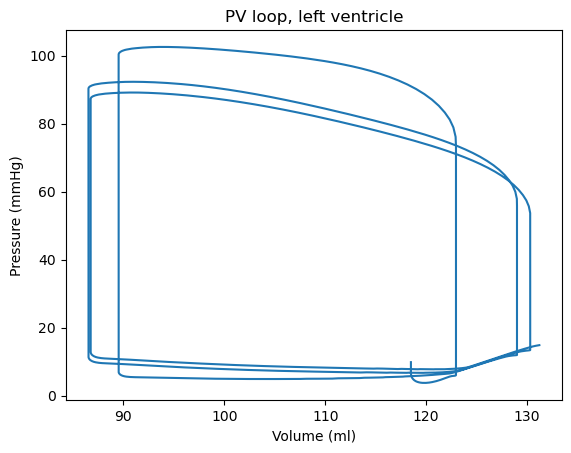

In [3]:
import matplotlib.pyplot as plt
df.plot("V_LV", "p_LV", xlabel="Volume (ml)", ylabel="Pressure (mmHg)", legend=None, title="PV loop, left ventricle")
plt.show()